In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

#Generate reproducible non linear data
np.random.seed(42)

X= np.linspace(0,10,40).reshape(-1,1)

#np.random.nornmal(0,5,40) is to generate random noise
# and add realistic variation to the output data
#np.random.normal(mean,standard_deviation,number of values) .......we are generrating random noise
y=2 + 0.5 * X[:,0] ** 2 +np.random.normal(0,5,40)

#divide the data
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.30,random_state=42
)

degrees=[1,2,10]

#include bias= false-is to tell plynomialfeatures not to create
#an additional constant column containing only 1s

for degree in degrees:
    model=make_pipeline(
        PolynomialFeatures(degree=degree,include_bias=False),
        LinearRegression()
    )
    model.fit(X_train,y_train)
    train_prediction=model.predict(X_train)
    test_prediction=model.predict(X_test)

    train_mse = mean_squared_error(y_train,train_prediction)
    test_mse = mean_squared_error(y_test,test_prediction)

    print(f"PolynomialFeatures:{degree}")
    print(f"Training Mse: {train_mse:.2f}")
    print(f"Testing MSE:{test_mse:.2f}")
    print()

    #underfit
    #best model
    #overfit

PolynomialFeatures:1
Training Mse: 42.90
Testing MSE:42.99

PolynomialFeatures:2
Training Mse: 20.44
Testing MSE:19.79

PolynomialFeatures:10
Training Mse: 18.26
Testing MSE:38.42



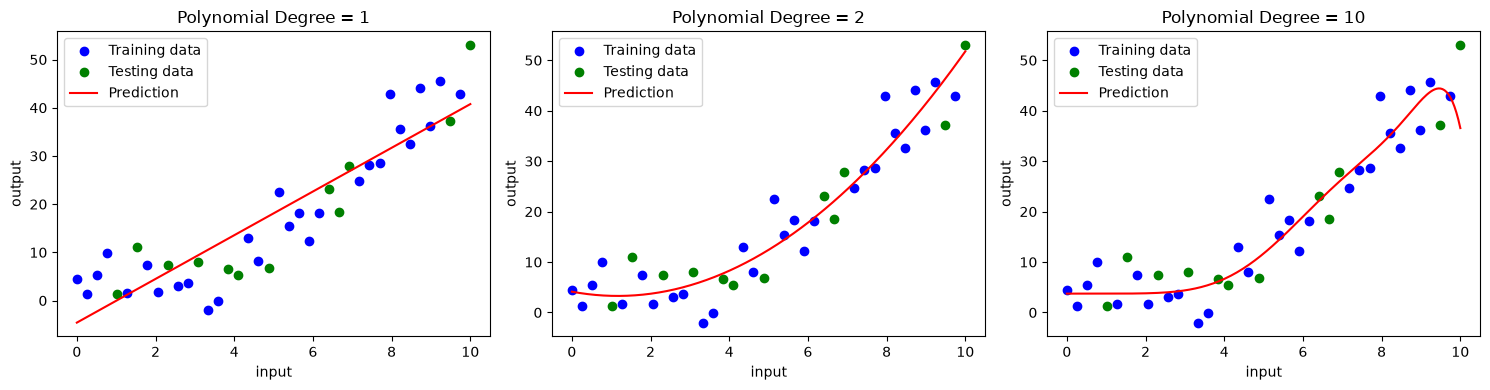

In [2]:
x_plot = np.linspace(0,10,200).reshape(-1,1)
plt.figure(figsize=(15,4))

for index,degree in enumerate(degrees):
    model=make_pipeline(
        PolynomialFeatures(degree=degree,include_bias=False),
        LinearRegression()
    )

    model.fit(X_train,y_train)
    y_plot=model.predict(x_plot)

    plt.subplot(1,3,index+1)
    plt.scatter(X_train,y_train,color="blue",label="Training data")
    plt.scatter(X_test,y_test,color="green",label="Testing data")
    plt.plot(x_plot,y_plot,color="red",label="Prediction")

    plt.title(f"Polynomial Degree = {degree}")
    plt.xlabel("input")
    plt.ylabel("output")
    plt.legend()

plt.tight_layout()
plt.show()


cross validation and model selection

In [3]:
from sklearn.model_selection import cross_val_score
for degree in range(1,11):
    model=make_pipeline(
            PolynomialFeatures(degree=degree,include_bias=False),
            LinearRegression()
        )

    scores=cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="neg_mean_squared_error"
        #scikit learn returns the negative value of
        #the mean squared (MSE)
        #so that higher (less negative) values
        #represent better model performance
    )

    mean_mse=scores.mean()

    print(f"Degree{degree}:CV MSE = {mean_mse:.2f}")


Degree1:CV MSE = -110.69
Degree2:CV MSE = -44.22
Degree3:CV MSE = -71.23
Degree4:CV MSE = -82.46
Degree5:CV MSE = -1346.32
Degree6:CV MSE = -7930.95
Degree7:CV MSE = -20375.98
Degree8:CV MSE = -31567.34
Degree9:CV MSE = -55109.01
Degree10:CV MSE = -67544.63


In [4]:
model.fit(X_train,y_train)
train_prediction=model.predict(X_train)
test_prediction=model.predict(X_test)

train_mse = mean_squared_error(y_train,train_prediction)
test_mse = mean_squared_error(y_test,test_prediction)

print(f"PolynomialFeatures:{degree}")
print(f"Training Mse: {train_mse:.2f}")
print(f"Testing MSE:{test_mse:.2f}")
print()

PolynomialFeatures:10
Training Mse: 18.26
Testing MSE:38.42



In [5]:
#change test size to 20,25,30  take degrees 1,2,3,4,5,10 take data 0,500,1000
X= np.linspace(0,500,1000).reshape(-1,1)
y=2 + 0.5 * X[:,0] ** 2 +np.random.normal(0,5,1000)

In [6]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.20,random_state=42
)
degrees=[1,2,3,4,5,10]

for degree in degrees:
    model=make_pipeline(
        PolynomialFeatures(degree=degree,include_bias=False),
        LinearRegression()
    )
    model.fit(X_train,y_train)
    train_prediction=model.predict(X_train)
    test_prediction=model.predict(X_test)

    train_mse = mean_squared_error(y_train,train_prediction)
    test_mse = mean_squared_error(y_test,test_prediction)

    print(f"PolynomialFeatures:{degree}")
    print(f"Training Mse: {train_mse:.2f}")
    print(f"Testing MSE:{test_mse:.2f}")
    print()


PolynomialFeatures:1
Training Mse: 87452332.66
Testing MSE:86134907.07

PolynomialFeatures:2
Training Mse: 23.79
Testing MSE:24.18

PolynomialFeatures:3
Training Mse: 23.82
Testing MSE:24.05

PolynomialFeatures:4
Training Mse: 3196351.93
Testing MSE:3017324.49

PolynomialFeatures:5
Training Mse: 16182272.82
Testing MSE:15238757.10

PolynomialFeatures:10
Training Mse: 177805603.95
Testing MSE:186251528.46



test size=0.2, Applying standard scaler

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

degrees = [1, 2, 3, 4, 5, 10]

for degree in degrees:
    model = make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )

    model.fit(X_train, y_train)

    train_prediction = model.predict(X_train)
    test_prediction = model.predict(X_test)

    train_mse = mean_squared_error(y_train, train_prediction)
    test_mse = mean_squared_error(y_test, test_prediction)

    print(f"Polynomial Degree: {degree}")
    print(f"Training MSE: {train_mse:.2f}")
    print(f"Testing MSE: {test_mse:.2f}")
    print()


Polynomial Degree: 1
Training MSE: 87452332.66
Testing MSE: 86134907.07

Polynomial Degree: 2
Training MSE: 23.79
Testing MSE: 24.18

Polynomial Degree: 3
Training MSE: 23.79
Testing MSE: 24.27

Polynomial Degree: 4
Training MSE: 23.72
Testing MSE: 24.21

Polynomial Degree: 5
Training MSE: 23.72
Testing MSE: 24.20

Polynomial Degree: 10
Training MSE: 23.69
Testing MSE: 24.36



TEST SIZE=0.25

In [8]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.25,random_state=42
)
degrees=[1,2,3,4,5,10]

for degree in degrees:
    model=make_pipeline(
        PolynomialFeatures(degree=degree,include_bias=False),
        LinearRegression()
    )
    model.fit(X_train,y_train)
    train_prediction=model.predict(X_train)
    test_prediction=model.predict(X_test)

    train_mse = mean_squared_error(y_train,train_prediction)
    test_mse = mean_squared_error(y_test,test_prediction)

    print(f"PolynomialFeatures:{degree}")
    print(f"Training Mse: {train_mse:.2f}")
    print(f"Testing MSE:{test_mse:.2f}")
    print()

PolynomialFeatures:1
Training Mse: 85827437.39
Testing MSE:91205975.71

PolynomialFeatures:2
Training Mse: 24.09
Testing MSE:23.27

PolynomialFeatures:3
Training Mse: 24.10
Testing MSE:23.21

PolynomialFeatures:4
Training Mse: 3163740.59
Testing MSE:3150958.43

PolynomialFeatures:5
Training Mse: 16030079.97
Testing MSE:15889182.92

PolynomialFeatures:10
Training Mse: 176550807.12
Testing MSE:188586240.85

